## Directory

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os 
from shapely.geometry import Point

main_dir =  os.path.dirname(os.path.dirname(os.getcwd()))


c:\Users\rjbar\anaconda3\envs\ramiro\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Number of treated grid cells (based on grid number)

In [2]:
acs = gpd.read_file('../data_output/intermediate/_0_2_2_final_ac_rural_clean_from_finalver15_only_polygon.shp')
acs['geometry'] = acs['geometry'].buffer(0)

grid = gpd.read_file("../data_output/intermediate/1-grid-generation.shp")

c:\Users\rjbar\anaconda3\envs\ramiro\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: ../data_output/intermediate/_0_2_2_final_ac_rural_clean_from_finalver15_only_polygon.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [3]:
# Read the shapefiles
acs = gpd.read_file('../data_output/intermediate/_0_2_2_final_ac_rural_clean_from_finalver15_only_polygon.shp')
acs['geometry'] = acs['geometry'].buffer(0)  # Ensure valid geometries

grid = gpd.read_file("../data_output/intermediate/1-grid-generation.shp")

# Spatial join to find grids that touch any polygon in acs
grid_with_acs = gpd.sjoin(grid, acs, how="left", predicate="intersects")

# Count grids that touch at least one polygon in acs
total_touching_grids = grid_with_acs['index_right'].notna().sum()

# Count grids that are split across multiple polygons
split_grids = grid_with_acs.groupby(grid_with_acs.index).filter(lambda x: x['index_right'].nunique() > 1)
split_grids_count = split_grids.index.nunique()

# Print the results
print(f"Total grids touching at least one polygon in acs: {total_touching_grids}")
print(f"Number of grids split across multiple polygons in acs: {split_grids_count}")


c:\Users\rjbar\anaconda3\envs\ramiro\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: ../data_output/intermediate/_0_2_2_final_ac_rural_clean_from_finalver15_only_polygon.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


Total grids touching at least one polygon in acs: 132062
Number of grids split across multiple polygons in acs: 29178


### Plots for the different Treatment Variation

In [4]:
# Load the shapefiles
acs = gpd.read_file('../data_output/intermediate/_0_2_2_final_ac_rural_clean_from_finalver15_only_polygon.shp')
acs['geometry'] = acs['geometry'].buffer(0)  # Fix invalid geometries

grid = gpd.read_file("../data_output/intermediate/1-grid-generation.shp")

c:\Users\rjbar\anaconda3\envs\ramiro\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: ../data_output/intermediate/_0_2_2_final_ac_rural_clean_from_finalver15_only_polygon.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


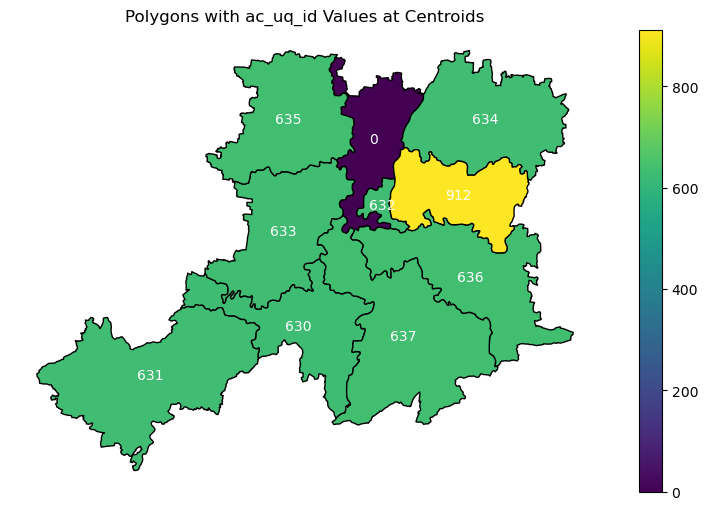

In [5]:
# Selecting ac_uq_id = 912
acs_subset = acs.head(n=10).copy()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
acs_subset.plot(column="ac_uq_id", cmap="viridis", edgecolor="black", legend=True, ax=ax)

# Add text labels at centroids
for idx, row in acs_subset.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, str(row["ac_uq_id"]), fontsize=10, ha='center', va='center', color='white')

ax.set_title("Polygons with ac_uq_id Values at Centroids")
ax.axis("off")  # Remove axis for better visualization

plt.show()


In [6]:
# Area of Grids
grid['area_grid'] = grid.to_crs(7755).area
inter_grid_ac = gpd.overlay(grid, acs)

# Intersection of Grids
inter_grid_ac['inter_grid_area'] = inter_grid_ac.to_crs(7755).area
inter_grid_ac['frac_area_grid'] = inter_grid_ac['inter_grid_area'] * 100 / inter_grid_ac['area_grid']
inter_grid_ac = inter_grid_ac.reset_index(drop = True)

# Selecting grids with highest share of area in an ACs
idxmax = inter_grid_ac.groupby('unq_s__')['frac_area_grid'].idxmax()
max_area_grid = inter_grid_ac.loc[ idxmax ].copy() \
                        .reset_index(drop = True)

# Selecting the grids for ACs 912
grid_idx = max_area_grid.query('ac_uq_id == 912')['unq_s__'].tolist()

c:\Users\rjbar\anaconda3\envs\ramiro\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 8 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [7]:
# Selecting grids
selected_grids = grid[grid.unq_s__.isin(grid_idx)].copy()

In [8]:
# Selecting the AC value
selected_polygon = acs.query(' ac_uq_id == 912')

In [9]:
# selected_polygon
# wazirganj in Bihar state

C:\Users\rjbar\AppData\Local\Temp\ipykernel_3168\132767922.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grid.geometry.centroid.iloc[0]


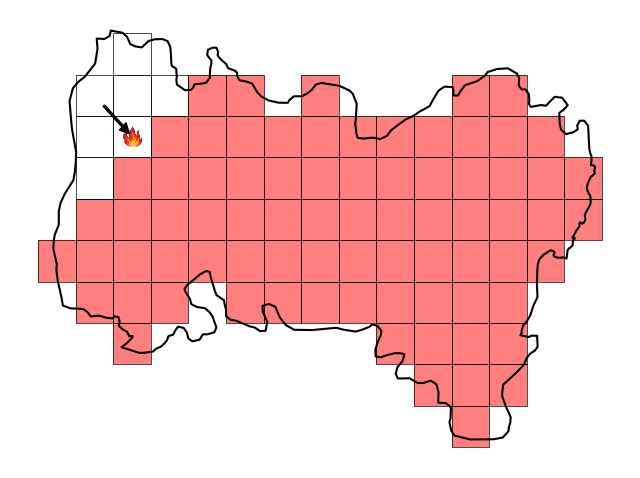

In [10]:
import matplotlib.image as mpimg

# Select the grid where unq_s__ == 7289
selected_grid = selected_grids[selected_grids["unq_s__"] == 7289]

# Get the centroid of the selected grid
centroid = selected_grid.geometry.centroid.iloc[0]

# Define the arrow direction: NE to SW (45-degree slope)
arrow_dx = 1  # Moving left (west)
arrow_dy = -1  # Moving down (south)

# Compute the perpendicular line equation: y = mx + c
m_arrow = arrow_dy / arrow_dx  # Slope of the arrow (-1)
m_perpendicular = 1  # Perpendicular slope (inverse and negation of arrow slope)
c_perpendicular = centroid.y - m_perpendicular * centroid.x

# Identify grids below the perpendicular line
def is_below_perpendicular(geometry):
    x, y = geometry.centroid.x, geometry.centroid.y
    return y < (m_perpendicular * x + c_perpendicular)

selected_grids["below_line"] = selected_grids.geometry.apply(is_below_perpendicular)
filter1 = selected_grids.unq_s__.isin([7295, 7283])
selected_grids.loc[filter1, 'below_line'] = False

# Load fire image
fire_img_path = "../data_output/intermediate/fire.png"
fire_img = mpimg.imread(fire_img_path)



# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5)
selected_grids[selected_grids["below_line"]].plot(ax=ax, color="red", alpha=0.5)

# Overlay the fire image at the centroid
# New extent for a smaller fire image
fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor
]
ax.imshow(fire_img, extent=img_extent, aspect='auto', zorder=9)


# Draw the arrow
ax.arrow(
    centroid.x-0.015, centroid.y+0.015, arrow_dx * 0.01, arrow_dy * 0.01,  # Adjust arrow length
    head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11
)

selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5, label="Selected Polygon")


# Show the plot
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.title("Fire and Affected Grids")
ax.axis("off")  # Remove axis for better visualization
save_path = "../tex/paper/figures/explaindw2_ac.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()


C:\Users\rjbar\AppData\Local\Temp\ipykernel_3168\1378327706.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grid.geometry.centroid.iloc[0]


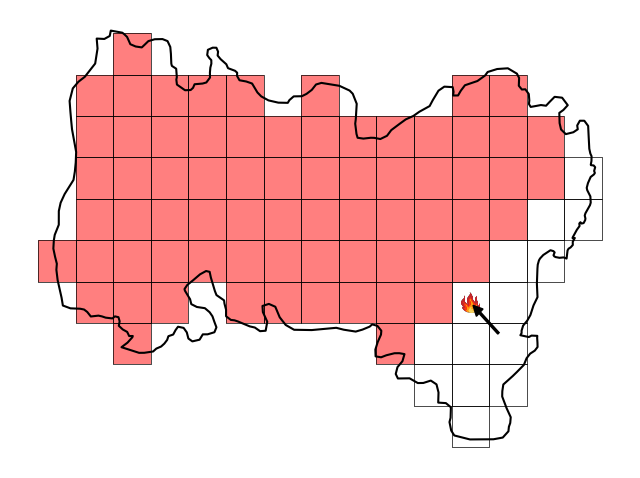

In [11]:
import matplotlib.image as mpimg

# Select the grid where unq_s__ == 7289
selected_grid = selected_grids[selected_grids["unq_s__"] == 5818]

# Get the centroid of the selected grid
centroid = selected_grid.geometry.centroid.iloc[0]

# Define the arrow direction: NE to SW (45-degree slope)
arrow_dx = -1  # Moving left (west)
arrow_dy = 1  # Moving down (south)

# Compute the perpendicular line equation: y = mx + c
m_arrow = arrow_dy / arrow_dx  # Slope of the arrow (-1)
m_perpendicular = 1  # Perpendicular slope (inverse and negation of arrow slope)
c_perpendicular = centroid.y - m_perpendicular * centroid.x

# Identify grids below the perpendicular line
def is_below_perpendicular(geometry):
    x, y = geometry.centroid.x, geometry.centroid.y
    return y > (m_perpendicular * x + c_perpendicular)

selected_grids["below_line"] = selected_grids.geometry.apply(is_below_perpendicular)
filter1 = selected_grids.unq_s__.isin([7356])
selected_grids.loc[filter1, 'below_line'] = False

# Load fire image
fire_img_path = "../data_output/intermediate/fire.png"
fire_img = mpimg.imread(fire_img_path)



# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5)
selected_grids[selected_grids["below_line"]].plot(ax=ax, color="red", alpha=0.5)

# Overlay the fire image at the centroid
# New extent for a smaller fire image
fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor
]
ax.imshow(fire_img, extent=img_extent, aspect='auto', zorder=9)


# Draw the arrow
ax.arrow(
    centroid.x+0.015, centroid.y-0.015, arrow_dx * 0.01, arrow_dy * 0.01,  # Adjust arrow length
    head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11
)

selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5, label="Selected Polygon")


# Show the plot
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.title("Fire and Affected Grids")
ax.axis("off")  # Remove axis for better visualization
save_path = "../tex/paper/figures/explaindw4_ac.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()


C:\Users\rjbar\AppData\Local\Temp\ipykernel_3168\3948077965.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grid.geometry.centroid.iloc[0]


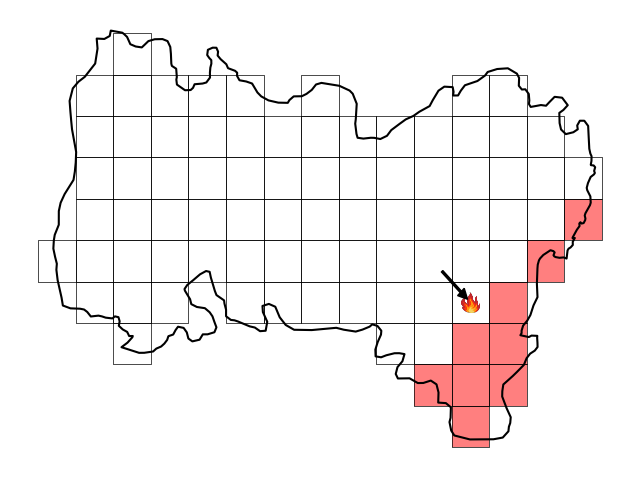

In [12]:
import matplotlib.image as mpimg

# Select the grid where unq_s__ == 7289
selected_grid = selected_grids[selected_grids["unq_s__"] == 5818]

# Get the centroid of the selected grid
centroid = selected_grid.geometry.centroid.iloc[0]

# Define the arrow direction: NE to SW (45-degree slope)
arrow_dx = 1  # Moving left (west)
arrow_dy = -1  # Moving down (south)

# Compute the perpendicular line equation: y = mx + c
m_arrow = arrow_dy / arrow_dx  # Slope of the arrow (-1)
m_perpendicular = 1  # Perpendicular slope (inverse and negation of arrow slope)
c_perpendicular = centroid.y - m_perpendicular * centroid.x

# Identify grids below the perpendicular line
def is_below_perpendicular(geometry):
    x, y = geometry.centroid.x, geometry.centroid.y
    return y < (m_perpendicular * x + c_perpendicular)

selected_grids["below_line"] = selected_grids.geometry.apply(is_below_perpendicular)
filter1 = selected_grids.unq_s__.isin([5824, 7330, 5812])
selected_grids.loc[filter1, 'below_line'] = False

# Load fire image
fire_img_path = "../data_output/intermediate/fire.png"
fire_img = mpimg.imread(fire_img_path)



# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5)
selected_grids[selected_grids["below_line"]].plot(ax=ax, color="red", alpha=0.5)

# Overlay the fire image at the centroid
# New extent for a smaller fire image
fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor
]
ax.imshow(fire_img, extent=img_extent, aspect='auto', zorder=9)


# Draw the arrow
ax.arrow(
    centroid.x-0.015, centroid.y+0.015, arrow_dx * 0.01, arrow_dy * 0.01,  # Adjust arrow length
    head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11
)

selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5, label="Selected Polygon")


# Show the plot
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.title("Fire and Affected Grids")
ax.axis("off")  # Remove axis for better visualization
save_path = "../tex/paper/figures/explaindw3_ac.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()


## Number of treated grid cells (based on sum of population affected in grids)

In [13]:
from exactextract import exact_extract

# GPW v4 population *density* raster (persons per km^2), 30 arc-sec (~1km), EPSG:4326
pop_tif = os.path.join(
    main_dir, "data", "input", "population_density", "sedac",
    "gpw-v4-population-density-rev11_2015_30_sec_tif",
    "gpw_v4_population_density_rev11_2015_30_sec.tif",
)

# Area-weighted mean density within each grid cell.
# exact_extract weights each pixel by its fractional overlap with the grid
# and skips nodata (water), so partial-coverage cells are handled correctly.
grid["mean_pop_density"] = exact_extract(pop_tif, grid, ["mean"], output="pandas")["mean"].values

# Grid area in km^2 (project to the metric CRS used elsewhere in this notebook)
grid["area_km2"] = grid.to_crs(7755).area / 1e6

# Population per grid = density (persons/km^2) * area (km^2)
grid["population"] = grid["mean_pop_density"].fillna(0) * grid["area_km2"]

population = grid  # GeoDataFrame with a per-grid `population` column
population[["unq_s__", "mean_pop_density", "area_km2", "population"]].head()

c:\Users\rjbar\anaconda3\envs\ramiro\Lib\site-packages\osgeo\gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


,unq_s__,mean_pop_density,area_km2,population
0,1,132.321182,4.34075,574.373220
1,2,132.321182,4.34075,574.373220
2,3,132.321179,4.34075,574.373206
3,4,132.321177,4.34075,574.373196
4,5,132.321174,4.34075,574.373184


In [14]:
# Population-weighted version of the treated-grid statistic above.
# Spatial join: which AC(s) each grid touches.
grid_with_acs = gpd.sjoin(population, acs, how="left", predicate="intersects")

# Number of distinct ACs each grid intersects (0 if it touches none).
acs_per_grid = grid_with_acs.groupby(grid_with_acs.index)["index_right"].nunique()

touching_idx = acs_per_grid[acs_per_grid >= 1].index   # grids touching >= 1 AC
split_idx    = acs_per_grid[acs_per_grid > 1].index     # grids split across multiple ACs

pop_touching = population.loc[touching_idx, "population"].sum()
pop_split    = population.loc[split_idx,    "population"].sum()

print(f"Population in grids touching at least one AC: {pop_touching:,.0f}")
print(f"Population in grids split across multiple ACs: {pop_split:,.0f}")
print(f"Share of affected population in split grids:   {pop_split / pop_touching:.4f}")

Population in grids touching at least one AC: 382,026,238
Population in grids split across multiple ACs: 126,338,027
Share of affected population in split grids:   0.3307


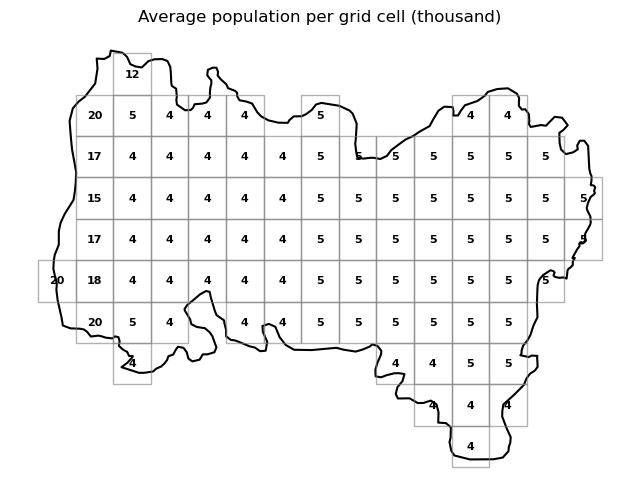

In [15]:
# Plot the same set of grids (around unq_s__ == 7289), labelled with the
# average population per grid cell in dark letters.

# Bring the per-grid population computed above onto the selected grids
# (selected_grids was copied before the population column was added).
pop_by_grid = population.set_index("unq_s__")["population"]
selected_grids["population"] = selected_grids["unq_s__"].map(pop_by_grid)
selected_grids["population"] = round(selected_grids["population"] / 1000, None)

fig, ax = plt.subplots(figsize=(8, 6))

# AC boundary for context
selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5)

# Grid cells
selected_grids.plot(ax=ax, color="none", edgecolor="gray", alpha=0.6)

# Population label at each grid centroid, in dark letters
for _, row in selected_grids.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, f"{row['population']:.0f}",
            fontsize=8, ha="center", va="center", color="black", fontweight="bold")

ax.set_title("Average population per grid cell (thousand)")
ax.axis("off")
plt.show()

## Treatment-variation plots with population fraction (under-wind / total)

Same three explanatory plots as above, each with a fraction below it:
the summed population of the grids **under the wind** (red) over the summed
population of **all** grids in the AC.

C:\Users\rjbar\AppData\Local\Temp\ipykernel_18300\2377614773.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grid.geometry.centroid.iloc[0]


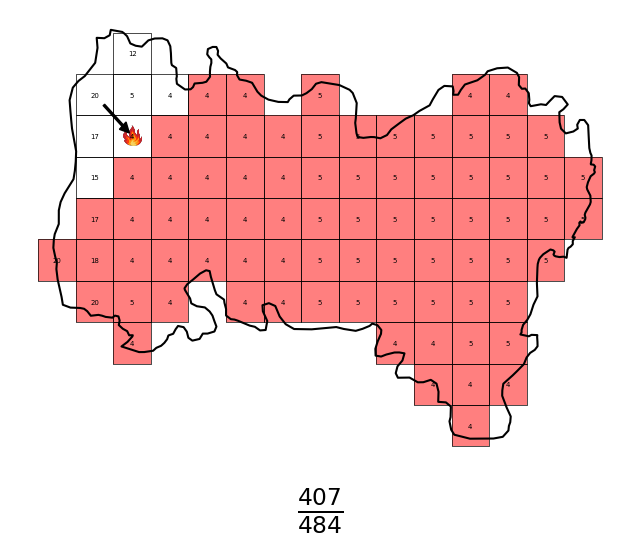

In [16]:
import matplotlib.image as mpimg

# Select the grid where unq_s__ == 7289
selected_grid = selected_grids[selected_grids["unq_s__"] == 7289]

# Get the centroid of the selected grid
centroid = selected_grid.geometry.centroid.iloc[0]

# Define the arrow direction: NE to SW (45-degree slope)
arrow_dx = 1  # Moving left (west)
arrow_dy = -1  # Moving down (south)

# Compute the perpendicular line equation: y = mx + c
m_arrow = arrow_dy / arrow_dx  # Slope of the arrow (-1)
m_perpendicular = 1  # Perpendicular slope (inverse and negation of arrow slope)
c_perpendicular = centroid.y - m_perpendicular * centroid.x

# Identify grids below the perpendicular line
def is_below_perpendicular(geometry):
    x, y = geometry.centroid.x, geometry.centroid.y
    return y < (m_perpendicular * x + c_perpendicular)

selected_grids["below_line"] = selected_grids.geometry.apply(is_below_perpendicular)
filter1 = selected_grids.unq_s__.isin([7295, 7283])
selected_grids.loc[filter1, 'below_line'] = False

# Population per grid (mapped from the per-grid population computed above)
selected_grids["population"] = selected_grids["unq_s__"].map(
    population.set_index("unq_s__")["population"])

selected_grids["population"] = round(selected_grids["population"]/1000,0)

# Load fire image
fire_img_path = "../data_output/intermediate/fire.png"
fire_img = mpimg.imread(fire_img_path)



# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5)
selected_grids[selected_grids["below_line"]].plot(ax=ax, color="red", alpha=0.5)

# Overlay the fire image at the centroid
# New extent for a smaller fire image
fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor
]
ax.imshow(fire_img, extent=img_extent, aspect='auto', zorder=9)


# Draw the arrow
ax.arrow(
    centroid.x-0.015, centroid.y+0.015, arrow_dx * 0.01, arrow_dy * 0.01,  # Adjust arrow length
    head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11
)

selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5, label="Selected Polygon")

# Label each grid with its population (dark text at the grid centroid)
for _, row in selected_grids.iterrows():
    gc = row.geometry.centroid
    ax.text(gc.x, gc.y, f"{row['population']:.0f}",
            fontsize=5, ha="center", va="center", color="black", zorder=12)

ax.axis("off")  # Remove axis for better visualization

# Population fraction below the plot: under-the-wind (red) grids / all grids in the AC
# Numerator and denominator rounded to thousands (K)
num = selected_grids.loc[selected_grids["below_line"], "population"].sum()
den = selected_grids["population"].sum()
ax.text(0.5, -0.04, rf"$\frac{{{num:,.0f}}}{{{den:,.0f}}}$",
        transform=ax.transAxes, ha="center", va="top", fontsize=24)

save_path = "../tex/paper/figures/explaindw2_ac_pop.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()


C:\Users\rjbar\AppData\Local\Temp\ipykernel_18300\3345938547.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grid.geometry.centroid.iloc[0]


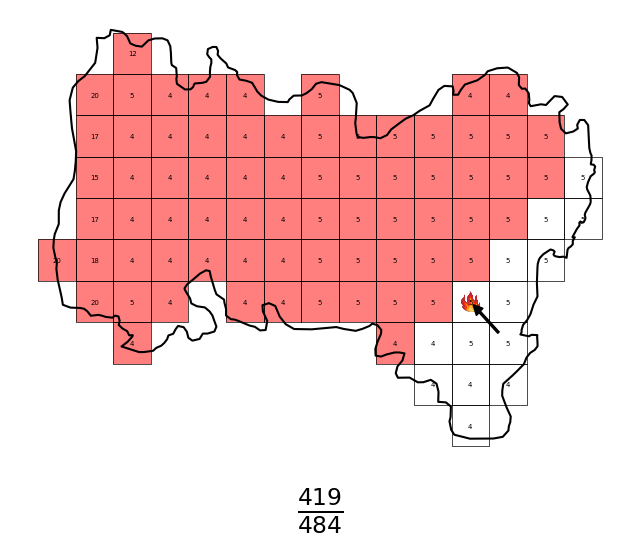

In [17]:
# Select the grid where unq_s__ == 5818
selected_grid = selected_grids[selected_grids["unq_s__"] == 5818]

# Get the centroid of the selected grid
centroid = selected_grid.geometry.centroid.iloc[0]

# Define the arrow direction: SW to NE
arrow_dx = -1  # Moving left (west)
arrow_dy = 1  # Moving down (south)

# Compute the perpendicular line equation: y = mx + c
m_arrow = arrow_dy / arrow_dx  # Slope of the arrow (-1)
m_perpendicular = 1  # Perpendicular slope (inverse and negation of arrow slope)
c_perpendicular = centroid.y - m_perpendicular * centroid.x

# Identify grids below the perpendicular line
def is_below_perpendicular(geometry):
    x, y = geometry.centroid.x, geometry.centroid.y
    return y > (m_perpendicular * x + c_perpendicular)

selected_grids["below_line"] = selected_grids.geometry.apply(is_below_perpendicular)
filter1 = selected_grids.unq_s__.isin([7356])
selected_grids.loc[filter1, 'below_line'] = False

# Population per grid (mapped from the per-grid population computed above)
selected_grids["population"] = selected_grids["unq_s__"].map(
    population.set_index("unq_s__")["population"])

selected_grids["population"] = round(selected_grids["population"]/1000,0)

# Load fire image
fire_img_path = "../data_output/intermediate/fire.png"
fire_img = mpimg.imread(fire_img_path)



# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5)
selected_grids[selected_grids["below_line"]].plot(ax=ax, color="red", alpha=0.5)

# Overlay the fire image at the centroid
# New extent for a smaller fire image
fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor
]
ax.imshow(fire_img, extent=img_extent, aspect='auto', zorder=9)


# Draw the arrow
ax.arrow(
    centroid.x+0.015, centroid.y-0.015, arrow_dx * 0.01, arrow_dy * 0.01,  # Adjust arrow length
    head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11
)

selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5, label="Selected Polygon")

# Label each grid with its population (dark text at the grid centroid)
for _, row in selected_grids.iterrows():
    gc = row.geometry.centroid
    ax.text(gc.x, gc.y, f"{row['population']:.0f}",
            fontsize=5, ha="center", va="center", color="black", zorder=12)

ax.axis("off")  # Remove axis for better visualization

# Population fraction below the plot: under-the-wind (red) grids / all grids in the AC
num = selected_grids.loc[selected_grids["below_line"], "population"].sum()
den = selected_grids["population"].sum()
ax.text(0.5, -0.04, rf"$\frac{{{num:,.0f}}}{{{den:,.0f}}}$",
        transform=ax.transAxes, ha="center", va="top", fontsize=24)

save_path = "../tex/paper/figures/explaindw4_ac_pop.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()


C:\Users\rjbar\AppData\Local\Temp\ipykernel_18300\2982372561.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grid.geometry.centroid.iloc[0]


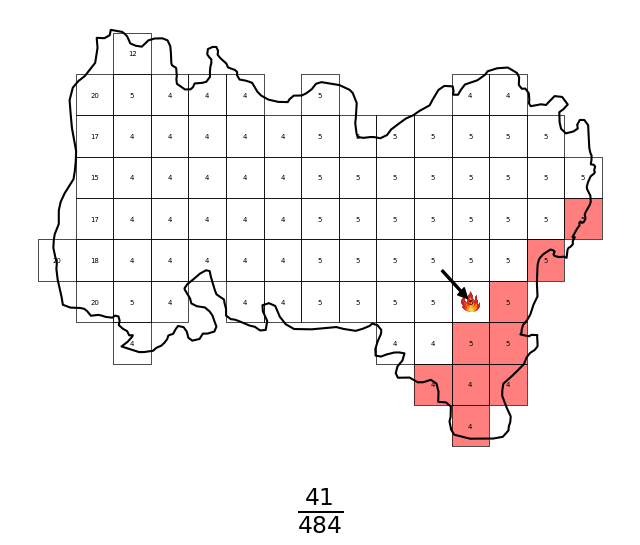

In [18]:
import matplotlib.image as mpimg

# Select the grid where unq_s__ == 5818
selected_grid = selected_grids[selected_grids["unq_s__"] == 5818]

# Get the centroid of the selected grid
centroid = selected_grid.geometry.centroid.iloc[0]

# Define the arrow direction: NE to SW (45-degree slope)
arrow_dx = 1  # Moving left (west)
arrow_dy = -1  # Moving down (south)

# Compute the perpendicular line equation: y = mx + c
m_arrow = arrow_dy / arrow_dx  # Slope of the arrow (-1)
m_perpendicular = 1  # Perpendicular slope (inverse and negation of arrow slope)
c_perpendicular = centroid.y - m_perpendicular * centroid.x

# Identify grids below the perpendicular line
def is_below_perpendicular(geometry):
    x, y = geometry.centroid.x, geometry.centroid.y
    return y < (m_perpendicular * x + c_perpendicular)

selected_grids["below_line"] = selected_grids.geometry.apply(is_below_perpendicular)
filter1 = selected_grids.unq_s__.isin([5824, 7330, 5812])
selected_grids.loc[filter1, 'below_line'] = False

# Population per grid (mapped from the per-grid population computed above)
selected_grids["population"] = selected_grids["unq_s__"].map(
    population.set_index("unq_s__")["population"])

selected_grids["population"] = round(selected_grids["population"]/1000,0)

# Load fire image
fire_img_path = "../data_output/intermediate/fire.png"
fire_img = mpimg.imread(fire_img_path)



# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5)
selected_grids[selected_grids["below_line"]].plot(ax=ax, color="red", alpha=0.5)

# Overlay the fire image at the centroid
# New extent for a smaller fire image
fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor
]
ax.imshow(fire_img, extent=img_extent, aspect='auto', zorder=9)


# Draw the arrow
ax.arrow(
    centroid.x-0.015, centroid.y+0.015, arrow_dx * 0.01, arrow_dy * 0.01,  # Adjust arrow length
    head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11
)

selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5, label="Selected Polygon")

# Label each grid with its population (dark text at the grid centroid)
for _, row in selected_grids.iterrows():
    gc = row.geometry.centroid
    ax.text(gc.x, gc.y, f"{row['population']:.0f}",
            fontsize=5, ha="center", va="center", color="black", zorder=12)

ax.axis("off")  # Remove axis for better visualization

# Population fraction below the plot: under-the-wind (red) grids / all grids in the AC
num = selected_grids.loc[selected_grids["below_line"], "population"].sum()
den = selected_grids["population"].sum()
ax.text(0.5, -0.04, rf"$\frac{{{num:,.0f}}}{{{den:,.0f}}}$",
        transform=ax.transAxes, ha="center", va="top", fontsize=24)

save_path = "../tex/paper/figures/explaindw3_ac_pop.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()


### Color Map Scheme

C:\Users\rjbar\AppData\Local\Temp\ipykernel_18300\1204552345.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grid.geometry.centroid.iloc[0]


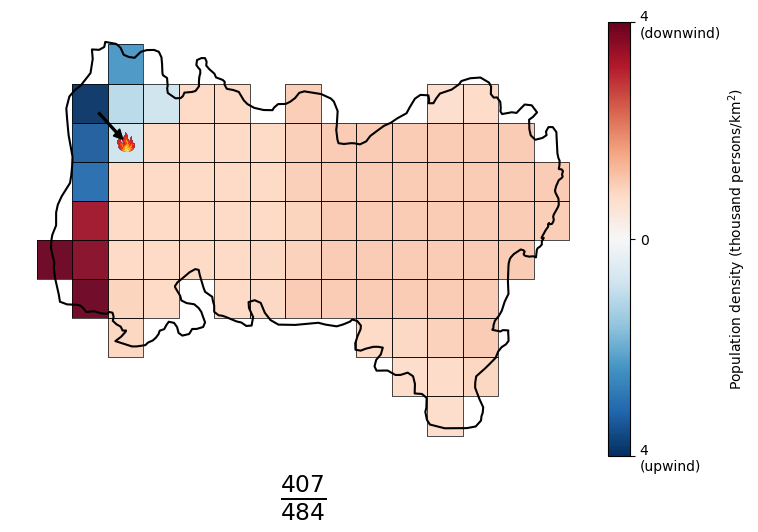

In [19]:
import matplotlib.image as mpimg
import numpy as np
from matplotlib.colors import Normalize

# Select the grid where unq_s__ == 7289
selected_grid = selected_grids[selected_grids["unq_s__"] == 7289]

# Get the centroid of the selected grid
centroid = selected_grid.geometry.centroid.iloc[0]

# Define the arrow direction: NE to SW (45-degree slope)
arrow_dx = 1  # Moving left (west)
arrow_dy = -1  # Moving down (south)

# Compute the perpendicular line equation: y = mx + c
m_arrow = arrow_dy / arrow_dx  # Slope of the arrow (-1)
m_perpendicular = 1  # Perpendicular slope (inverse and negation of arrow slope)
c_perpendicular = centroid.y - m_perpendicular * centroid.x

# Identify grids below the perpendicular line
def is_below_perpendicular(geometry):
    x, y = geometry.centroid.x, geometry.centroid.y
    return y < (m_perpendicular * x + c_perpendicular)

selected_grids["below_line"] = selected_grids.geometry.apply(is_below_perpendicular)
filter1 = selected_grids.unq_s__.isin([7295, 7283])
selected_grids.loc[filter1, 'below_line'] = False

# Population per grid (mapped from the per-grid population computed above)
selected_grids["population"] = selected_grids["unq_s__"].map(
    population.set_index("unq_s__")["population"])

selected_grids["population"] = round(selected_grids["population"]/1000,0)

# Population density per grid (persons/km^2) used to shade the grids
selected_grids["dens"] = selected_grids["unq_s__"].map(
    population.set_index("unq_s__")["mean_pop_density"])

# Signed density: positive (red) if below_line/downwind, negative (blue) otherwise.
# White at 0; darker with higher density on either side.
selected_grids["signed_dens"] = np.where(
    selected_grids["below_line"], selected_grids["dens"], -selected_grids["dens"])
maxabs = selected_grids["dens"].max()
maxabs_k = int(maxabs / 1000)  # legend value in thousands (e.g. 4626 -> 4)
norm = Normalize(vmin=-maxabs, vmax=maxabs)
cmap = "RdBu_r"

# Load fire image
fire_img_path = "../data_output/intermediate/fire.png"
fire_img = mpimg.imread(fire_img_path)


# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
selected_grids.plot(ax=ax, column="signed_dens", cmap=cmap, norm=norm, alpha=0.95)
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5, zorder=5)

# Overlay the fire image at the centroid
# New extent for a smaller fire image
fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor
]
ax.imshow(fire_img, extent=img_extent, aspect='auto', zorder=9)


# Draw the arrow
ax.arrow(
    centroid.x-0.015, centroid.y+0.015, arrow_dx * 0.01, arrow_dy * 0.01,  # Adjust arrow length
    head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11
)

selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5, zorder=6, label="Selected Polygon")

ax.axis("off")  # Remove axis for better visualization

# Colorbar legend: darker red (top) = densest downwind, white (middle) = 0,
# darker blue (bottom) = densest upwind. Labels in thousands of persons/km^2.
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02, ticks=[-maxabs, 0, maxabs])
cbar.ax.set_yticklabels([f"{maxabs_k}\n(upwind)", "0", f"{maxabs_k}\n(downwind)"])
cbar.set_label("Population density (thousand persons/km$^2$)")

# Population fraction below the plot: under-the-wind (red) grids / all grids in the AC
num = selected_grids.loc[selected_grids["below_line"], "population"].sum()
den = selected_grids["population"].sum()
ax.text(0.5, -0.04, rf"$\frac{{{num:,.0f}}}{{{den:,.0f}}}$",
        transform=ax.transAxes, ha="center", va="top", fontsize=24)

save_path = "../tex/paper/figures/explaindw2_ac_colormap.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()


C:\Users\rjbar\AppData\Local\Temp\ipykernel_18300\1528544188.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grid.geometry.centroid.iloc[0]


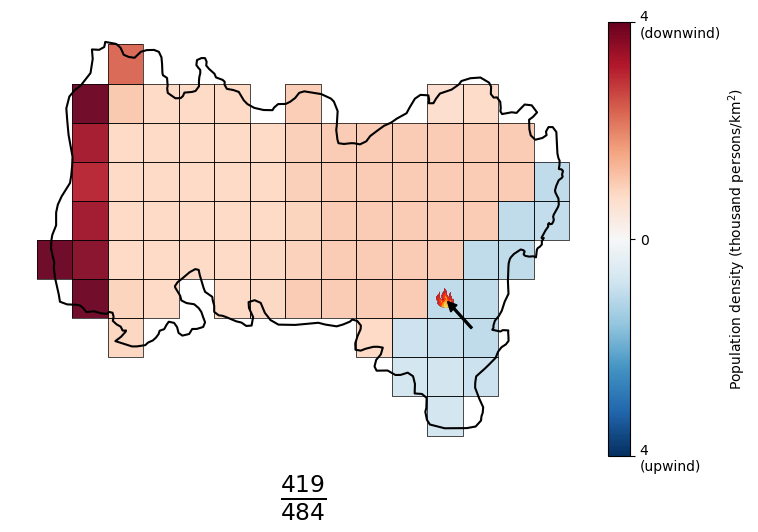

In [20]:
import matplotlib.image as mpimg
import numpy as np
from matplotlib.colors import Normalize

# Select the grid where unq_s__ == 5818
selected_grid = selected_grids[selected_grids["unq_s__"] == 5818]

# Get the centroid of the selected grid
centroid = selected_grid.geometry.centroid.iloc[0]

# Define the arrow direction: SW to NE
arrow_dx = -1  # Moving left (west)
arrow_dy = 1  # Moving down (south)

# Compute the perpendicular line equation: y = mx + c
m_arrow = arrow_dy / arrow_dx  # Slope of the arrow (-1)
m_perpendicular = 1  # Perpendicular slope (inverse and negation of arrow slope)
c_perpendicular = centroid.y - m_perpendicular * centroid.x

# Identify grids below the perpendicular line
def is_below_perpendicular(geometry):
    x, y = geometry.centroid.x, geometry.centroid.y
    return y > (m_perpendicular * x + c_perpendicular)

selected_grids["below_line"] = selected_grids.geometry.apply(is_below_perpendicular)
filter1 = selected_grids.unq_s__.isin([7356])
selected_grids.loc[filter1, 'below_line'] = False

# Population per grid (mapped from the per-grid population computed above)
selected_grids["population"] = selected_grids["unq_s__"].map(
    population.set_index("unq_s__")["population"])

selected_grids["population"] = round(selected_grids["population"]/1000,0)

# Population density per grid (persons/km^2) used to shade the grids
selected_grids["dens"] = selected_grids["unq_s__"].map(
    population.set_index("unq_s__")["mean_pop_density"])

# Signed density: positive (red) if below_line/downwind, negative (blue) otherwise.
# White at 0; darker with higher density on either side.
selected_grids["signed_dens"] = np.where(
    selected_grids["below_line"], selected_grids["dens"], -selected_grids["dens"])
maxabs = selected_grids["dens"].max()
maxabs_k = int(maxabs / 1000)  # legend value in thousands (e.g. 4626 -> 4)
norm = Normalize(vmin=-maxabs, vmax=maxabs)
cmap = "RdBu_r"

# Load fire image
fire_img_path = "../data_output/intermediate/fire.png"
fire_img = mpimg.imread(fire_img_path)


# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
selected_grids.plot(ax=ax, column="signed_dens", cmap=cmap, norm=norm, alpha=0.95)
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5, zorder=5)

# Overlay the fire image at the centroid
# New extent for a smaller fire image
fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor
]
ax.imshow(fire_img, extent=img_extent, aspect='auto', zorder=9)


# Draw the arrow
ax.arrow(
    centroid.x+0.015, centroid.y-0.015, arrow_dx * 0.01, arrow_dy * 0.01,  # Adjust arrow length
    head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11
)

selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5, zorder=6, label="Selected Polygon")

ax.axis("off")  # Remove axis for better visualization

# Colorbar legend: darker red (top) = densest downwind, white (middle) = 0,
# darker blue (bottom) = densest upwind. Labels in thousands of persons/km^2.
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02, ticks=[-maxabs, 0, maxabs])
cbar.ax.set_yticklabels([f"{maxabs_k}\n(upwind)", "0", f"{maxabs_k}\n(downwind)"])
cbar.set_label("Population density (thousand persons/km$^2$)")

# Population fraction below the plot: under-the-wind (red) grids / all grids in the AC
num = selected_grids.loc[selected_grids["below_line"], "population"].sum()
den = selected_grids["population"].sum()
ax.text(0.5, -0.04, rf"$\frac{{{num:,.0f}}}{{{den:,.0f}}}$",
        transform=ax.transAxes, ha="center", va="top", fontsize=24)

save_path = "../tex/paper/figures/explaindw4_ac_colormap.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()


C:\Users\rjbar\AppData\Local\Temp\ipykernel_18300\3464498536.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grid.geometry.centroid.iloc[0]


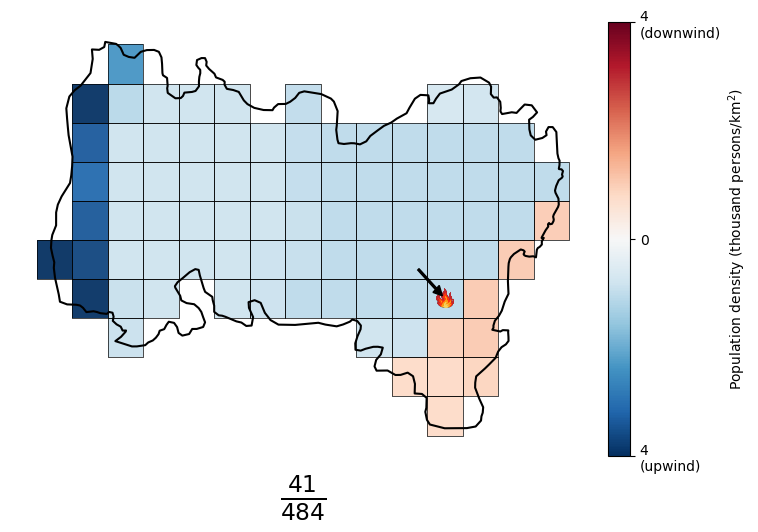

In [21]:
import matplotlib.image as mpimg
import numpy as np
from matplotlib.colors import Normalize

# Select the grid where unq_s__ == 5818
selected_grid = selected_grids[selected_grids["unq_s__"] == 5818]

# Get the centroid of the selected grid
centroid = selected_grid.geometry.centroid.iloc[0]

# Define the arrow direction: NE to SW (45-degree slope)
arrow_dx = 1  # Moving left (west)
arrow_dy = -1  # Moving down (south)

# Compute the perpendicular line equation: y = mx + c
m_arrow = arrow_dy / arrow_dx  # Slope of the arrow (-1)
m_perpendicular = 1  # Perpendicular slope (inverse and negation of arrow slope)
c_perpendicular = centroid.y - m_perpendicular * centroid.x

# Identify grids below the perpendicular line
def is_below_perpendicular(geometry):
    x, y = geometry.centroid.x, geometry.centroid.y
    return y < (m_perpendicular * x + c_perpendicular)

selected_grids["below_line"] = selected_grids.geometry.apply(is_below_perpendicular)
filter1 = selected_grids.unq_s__.isin([5824, 7330, 5812])
selected_grids.loc[filter1, 'below_line'] = False

# Population per grid (mapped from the per-grid population computed above)
selected_grids["population"] = selected_grids["unq_s__"].map(
    population.set_index("unq_s__")["population"])

selected_grids["population"] = round(selected_grids["population"]/1000,0)

# Population density per grid (persons/km^2) used to shade the grids
selected_grids["dens"] = selected_grids["unq_s__"].map(
    population.set_index("unq_s__")["mean_pop_density"])

# Signed density: positive (red) if below_line/downwind, negative (blue) otherwise.
# White at 0; darker with higher density on either side.
selected_grids["signed_dens"] = np.where(
    selected_grids["below_line"], selected_grids["dens"], -selected_grids["dens"])
maxabs = selected_grids["dens"].max()
maxabs_k = int(maxabs / 1000)  # legend value in thousands (e.g. 4626 -> 4)
norm = Normalize(vmin=-maxabs, vmax=maxabs)
cmap = "RdBu_r"

# Load fire image
fire_img_path = "../data_output/intermediate/fire.png"
fire_img = mpimg.imread(fire_img_path)


# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
selected_grids.plot(ax=ax, column="signed_dens", cmap=cmap, norm=norm, alpha=0.95)
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5, zorder=5)

# Overlay the fire image at the centroid
# New extent for a smaller fire image
fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor
]
ax.imshow(fire_img, extent=img_extent, aspect='auto', zorder=9)


# Draw the arrow
ax.arrow(
    centroid.x-0.015, centroid.y+0.015, arrow_dx * 0.01, arrow_dy * 0.01,  # Adjust arrow length
    head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11
)

selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5, zorder=6, label="Selected Polygon")

ax.axis("off")  # Remove axis for better visualization

# Colorbar legend: darker red (top) = densest downwind, white (middle) = 0,
# darker blue (bottom) = densest upwind. Labels in thousands of persons/km^2.
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02, ticks=[-maxabs, 0, maxabs])
cbar.ax.set_yticklabels([f"{maxabs_k}\n(upwind)", "0", f"{maxabs_k}\n(downwind)"])
cbar.set_label("Population density (thousand persons/km$^2$)")

# Population fraction below the plot: under-the-wind (red) grids / all grids in the AC
num = selected_grids.loc[selected_grids["below_line"], "population"].sum()
den = selected_grids["population"].sum()
ax.text(0.5, -0.04, rf"$\frac{{{num:,.0f}}}{{{den:,.0f}}}$",
        transform=ax.transAxes, ha="center", va="top", fontsize=24)

save_path = "../tex/paper/figures/explaindw3_ac_colormap.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()


## Map with 2 Colors

Same three plots but with only two flat colors: **light red** for the grids
under the line (downwind) and **light blue** for the grids above the line
(upwind). The fraction below is the population under the line (light red)
divided by the population above the line (light blue).

C:\Users\rjbar\AppData\Local\Temp\ipykernel_3168\4284768790.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grid.geometry.centroid.iloc[0]


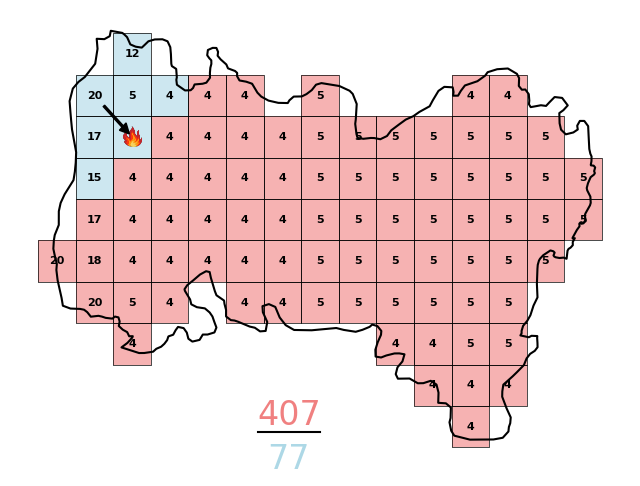

In [25]:
import matplotlib.image as mpimg

# Select the grid where unq_s__ == 7289
selected_grid = selected_grids[selected_grids["unq_s__"] == 7289]

# Get the centroid of the selected grid
centroid = selected_grid.geometry.centroid.iloc[0]

# Define the arrow direction: NE to SW (45-degree slope)
arrow_dx = 1  # Moving left (west)
arrow_dy = -1  # Moving down (south)

# Compute the perpendicular line equation: y = mx + c
m_arrow = arrow_dy / arrow_dx  # Slope of the arrow (-1)
m_perpendicular = 1  # Perpendicular slope (inverse and negation of arrow slope)
c_perpendicular = centroid.y - m_perpendicular * centroid.x

# Identify grids below the perpendicular line
def is_below_perpendicular(geometry):
    x, y = geometry.centroid.x, geometry.centroid.y
    return y < (m_perpendicular * x + c_perpendicular)

selected_grids["below_line"] = selected_grids.geometry.apply(is_below_perpendicular)
filter1 = selected_grids.unq_s__.isin([7295, 7283])
selected_grids.loc[filter1, 'below_line'] = False

# Population per grid (in thousands, rounded)
selected_grids["population"] = selected_grids["unq_s__"].map(
    population.set_index("unq_s__")["population"])
selected_grids["population"] = round(selected_grids["population"]/1000,0)

# Load fire image
fire_img_path = "../data_output/intermediate/fire.png"
fire_img = mpimg.imread(fire_img_path)


# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5)
# Two flat colors: light red under the line (downwind), light blue above (upwind)
selected_grids[selected_grids["below_line"]].plot(ax=ax, color="lightcoral", alpha=0.6)
selected_grids[~selected_grids["below_line"]].plot(ax=ax, color="lightblue", alpha=0.6)

# Overlay the fire image at the centroid
# New extent for a smaller fire image
fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor
]
ax.imshow(fire_img, extent=img_extent, aspect='auto', zorder=9)

# Draw the arrow
ax.arrow(
    centroid.x-0.015, centroid.y+0.015, arrow_dx * 0.01, arrow_dy * 0.01,  # Adjust arrow length
    head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11
)

selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5, label="Selected Polygon")

ax.axis("off")  # Remove axis for better visualization

# Population label at each grid centroid, in dark letters
for _, row in selected_grids.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, f"{row['population']:.0f}",
            fontsize=8, ha="center", va="center", color="black", fontweight="bold")

# Fraction: population under the line (light red numerator) over
# population above the line (light blue denominator)
num = selected_grids.loc[selected_grids["below_line"], "population"].sum()
den = selected_grids.loc[~selected_grids["below_line"], "population"].sum()
ax.text(0.45, 0.15, f"{num:,.0f}", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, color="lightcoral", clip_on=False)
ax.plot([0.4, 0.5], [0.08, 0.08], transform=ax.transAxes,
        color="black", lw=1.5, clip_on=False)
ax.text(0.45, 0.055, f"{den:,.0f}", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, color="lightblue", clip_on=False)

save_path = r"C:\Users\rjbar\Dropbox (Personal)\Aplicaciones\Overleaf\sa_fires_politicians\panel_A_downwind.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()


C:\Users\rjbar\AppData\Local\Temp\ipykernel_3168\21467680.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grid.geometry.centroid.iloc[0]


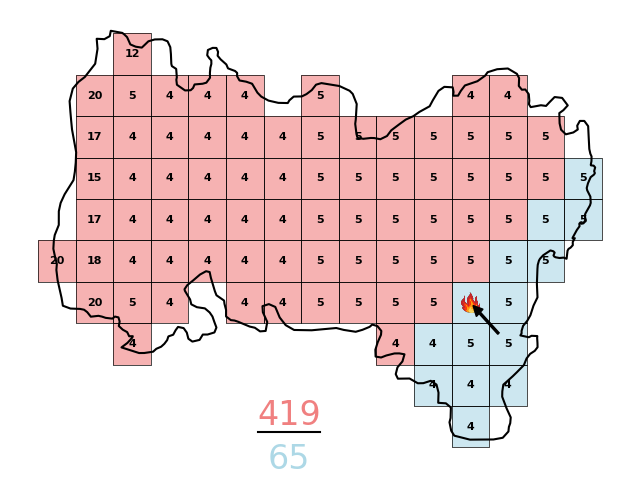

In [26]:
import matplotlib.image as mpimg

# Select the grid where unq_s__ == 5818
selected_grid = selected_grids[selected_grids["unq_s__"] == 5818]

# Get the centroid of the selected grid
centroid = selected_grid.geometry.centroid.iloc[0]

# Define the arrow direction: SW to NE
arrow_dx = -1  # Moving left (west)
arrow_dy = 1  # Moving down (south)

# Compute the perpendicular line equation: y = mx + c
m_arrow = arrow_dy / arrow_dx  # Slope of the arrow (-1)
m_perpendicular = 1  # Perpendicular slope (inverse and negation of arrow slope)
c_perpendicular = centroid.y - m_perpendicular * centroid.x

# Identify grids below the perpendicular line
def is_below_perpendicular(geometry):
    x, y = geometry.centroid.x, geometry.centroid.y
    return y > (m_perpendicular * x + c_perpendicular)

selected_grids["below_line"] = selected_grids.geometry.apply(is_below_perpendicular)
filter1 = selected_grids.unq_s__.isin([7356])
selected_grids.loc[filter1, 'below_line'] = False

# Population per grid (in thousands, rounded)
selected_grids["population"] = selected_grids["unq_s__"].map(
    population.set_index("unq_s__")["population"])
selected_grids["population"] = round(selected_grids["population"]/1000,0)

# Load fire image
fire_img_path = "../data_output/intermediate/fire.png"
fire_img = mpimg.imread(fire_img_path)



# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5)
# Two flat colors: light red under the line (downwind), light blue above (upwind)
selected_grids[selected_grids["below_line"]].plot(ax=ax, color="lightcoral", alpha=0.6)
selected_grids[~selected_grids["below_line"]].plot(ax=ax, color="lightblue", alpha=0.6)

# Overlay the fire image at the centroid
# New extent for a smaller fire image
fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor
]
ax.imshow(fire_img, extent=img_extent, aspect='auto', zorder=9)


# Draw the arrow
ax.arrow(
    centroid.x+0.015, centroid.y-0.015, arrow_dx * 0.01, arrow_dy * 0.01,  # Adjust arrow length
    head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11
)

selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5, label="Selected Polygon")

ax.axis("off")  # Remove axis for better visualization

# Population label at each grid centroid, in dark letters
for _, row in selected_grids.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, f"{row['population']:.0f}",
            fontsize=8, ha="center", va="center", color="black", fontweight="bold")

# Fraction: population under the line (light red numerator) over
# population above the line (light blue denominator)
num = selected_grids.loc[selected_grids["below_line"], "population"].sum()
den = selected_grids.loc[~selected_grids["below_line"], "population"].sum()
ax.text(0.45, 0.15, f"{num:,.0f}", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, color="lightcoral", clip_on=False)
ax.plot([0.4, 0.5], [0.08, 0.08], transform=ax.transAxes,
        color="black", lw=1.5, clip_on=False)
ax.text(0.45, 0.055, f"{den:,.0f}", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, color="lightblue", clip_on=False)

save_path = r"C:\Users\rjbar\Dropbox (Personal)\Aplicaciones\Overleaf\sa_fires_politicians\panel_C_upwind.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()


C:\Users\rjbar\AppData\Local\Temp\ipykernel_3168\3554371775.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grid.geometry.centroid.iloc[0]


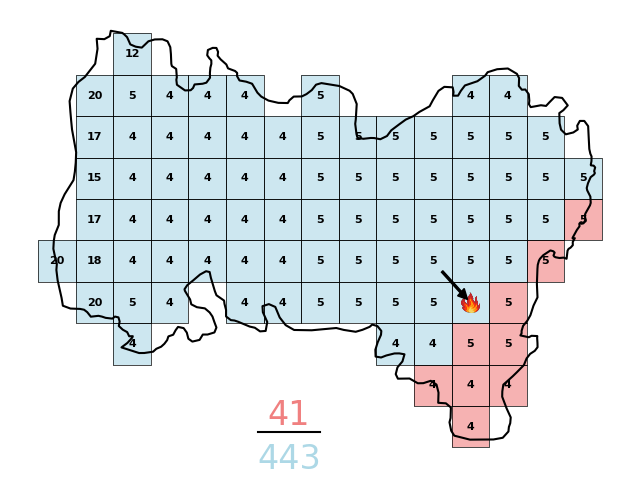

In [27]:
import matplotlib.image as mpimg

# Select the grid where unq_s__ == 5818
selected_grid = selected_grids[selected_grids["unq_s__"] == 5818]

# Get the centroid of the selected grid
centroid = selected_grid.geometry.centroid.iloc[0]

# Define the arrow direction: NE to SW (45-degree slope)
arrow_dx = 1  # Moving left (west)
arrow_dy = -1  # Moving down (south)

# Compute the perpendicular line equation: y = mx + c
m_arrow = arrow_dy / arrow_dx  # Slope of the arrow (-1)
m_perpendicular = 1  # Perpendicular slope (inverse and negation of arrow slope)
c_perpendicular = centroid.y - m_perpendicular * centroid.x

# Identify grids below the perpendicular line
def is_below_perpendicular(geometry):
    x, y = geometry.centroid.x, geometry.centroid.y
    return y < (m_perpendicular * x + c_perpendicular)

selected_grids["below_line"] = selected_grids.geometry.apply(is_below_perpendicular)
filter1 = selected_grids.unq_s__.isin([5824, 7330, 5812])
selected_grids.loc[filter1, 'below_line'] = False

# Population per grid (in thousands, rounded)
selected_grids["population"] = selected_grids["unq_s__"].map(
    population.set_index("unq_s__")["population"])
selected_grids["population"] = round(selected_grids["population"]/1000,0)

# Load fire image
fire_img_path = "../data_output/intermediate/fire.png"
fire_img = mpimg.imread(fire_img_path)



# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5)
# Two flat colors: light red under the line (downwind), light blue above (upwind)
selected_grids[selected_grids["below_line"]].plot(ax=ax, color="lightcoral", alpha=0.6)
selected_grids[~selected_grids["below_line"]].plot(ax=ax, color="lightblue", alpha=0.6)

# Overlay the fire image at the centroid
# New extent for a smaller fire image
fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor
]
ax.imshow(fire_img, extent=img_extent, aspect='auto', zorder=9)


# Draw the arrow
ax.arrow(
    centroid.x-0.015, centroid.y+0.015, arrow_dx * 0.01, arrow_dy * 0.01,  # Adjust arrow length
    head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11
)

selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5, label="Selected Polygon")

ax.axis("off")  # Remove axis for better visualization

# Population label at each grid centroid, in dark letters
for _, row in selected_grids.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, f"{row['population']:.0f}",
            fontsize=8, ha="center", va="center", color="black", fontweight="bold")

# Fraction: population under the line (light red numerator) over
# population above the line (light blue denominator)
num = selected_grids.loc[selected_grids["below_line"], "population"].sum()
den = selected_grids.loc[~selected_grids["below_line"], "population"].sum()
ax.text(0.45, 0.15, f"{num:,.0f}", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, color="lightcoral", clip_on=False)
ax.plot([0.4, 0.5], [0.08, 0.08], transform=ax.transAxes,
        color="black", lw=1.5, clip_on=False)
ax.text(0.45, 0.055, f"{den:,.0f}", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, color="lightblue", clip_on=False)

save_path = r"C:\Users\rjbar\Dropbox (Personal)\Aplicaciones\Overleaf\sa_fires_politicians\panel_B_downwind.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()


### Polygon Splitted

C:\Users\rjbar\AppData\Local\Temp\ipykernel_3168\1506066920.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grids[selected_grids["unq_s__"] == 7289].geometry.centroid.iloc[0]
C:\Users\rjbar\AppData\Local\Temp\ipykernel_3168\1506066920.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = selected_polygon.unary_union


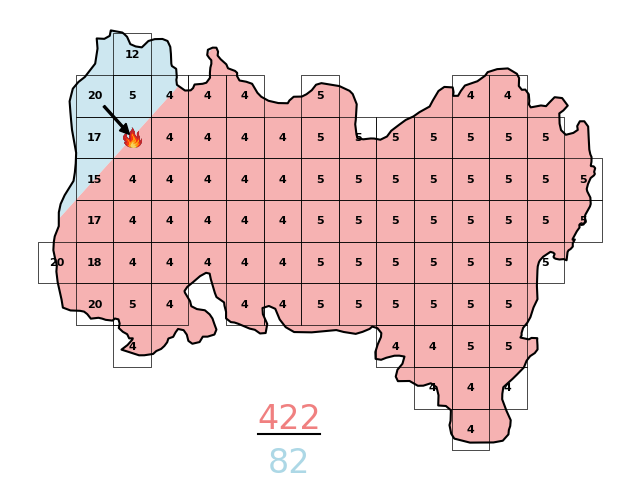

In [33]:
import matplotlib.image as mpimg
from shapely.geometry import LineString
from shapely.ops import split as shp_split, unary_union
from exactextract import exact_extract

# Population density raster (persons/km^2)
pop_tif = os.path.join(
    main_dir, "data", "input", "population_density", "sedac",
    "gpw-v4-population-density-rev11_2015_30_sec_tif",
    "gpw_v4_population_density_rev11_2015_30_sec.tif",
)

# --- Splitting line: same line as the dw2 plot (through fire grid 7289, slope 1) ---
centroid = selected_grids[selected_grids["unq_s__"] == 7289].geometry.centroid.iloc[0]
cp = centroid.y - centroid.x            # line: y = x + cp
arrow_dx, arrow_dy = 1, -1

# --- Split the AC polygon in two along the line ---
poly = selected_polygon.unary_union
minx, miny, maxx, maxy = poly.bounds
M = (maxx - minx) + (maxy - miny)       # extend the line well beyond the polygon
line = LineString([(minx - M, (minx - M) + cp), (maxx + M, (maxx + M) + cp)])

down, up = [], []
for g in shp_split(poly, line).geoms:
    rp = g.representative_point()
    # "under the line" (downwind) side for this plot: y < x + cp
    (down if rp.y < (rp.x + cp) else up).append(g)
down_poly = unary_union(down)
up_poly = unary_union(up)

# --- Population in each sub-polygon from the raster (mean density * area) ---
sub = gpd.GeoDataFrame({"side": ["down", "up"]},
                       geometry=[down_poly, up_poly], crs=selected_polygon.crs)
sub["mean_dens"] = exact_extract(pop_tif, sub, ["mean"], output="pandas")["mean"].values
sub["area_km2"] = sub.to_crs(7755).area / 1e6
sub["population"] = sub["mean_dens"].fillna(0) * sub["area_km2"]
num = round(sub.loc[sub.side == "down", "population"].iloc[0] / 1000, 0)  # light red
den = round(sub.loc[sub.side == "up",   "population"].iloc[0] / 1000, 0)  # light blue

# --- Fire image ---
fire_img = mpimg.imread("../data_output/intermediate/fire.png")

# --- Plotting ---
fig, ax = plt.subplots(figsize=(8, 6))
sub[sub.side == "down"].plot(ax=ax, color="lightcoral", alpha=0.6)
sub[sub.side == "up"].plot(ax=ax, color="lightblue", alpha=0.6)
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5)
selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5)

fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor,
]
ax.imshow(fire_img, extent=img_extent, aspect="auto", zorder=9)
ax.arrow(centroid.x + - 0.015, centroid.y + + 0.015, arrow_dx * 0.01, arrow_dy * 0.01,
         head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11)
ax.axis("off")


# Population label at each grid centroid, in dark letters
for _, row in selected_grids.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, f"{row['population']:.0f}",
            fontsize=8, ha="center", va="center", color="black", fontweight="bold")

# --- Fraction: population under the line (light red) / above the line (light blue) ---
ax.text(0.45, 0.15, f"{num:,.0f}", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, color="lightcoral", clip_on=False)
ax.plot([0.4, 0.5], [0.08, 0.08], transform=ax.transAxes,
        color="black", lw=1.5, clip_on=False)
ax.text(0.45, 0.055, f"{den:,.0f}", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, color="lightblue", clip_on=False)

save_path = r"C:\Users\rjbar\Dropbox (Personal)\Aplicaciones\Overleaf\sa_fires_politicians\panel_A_downwind.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()


C:\Users\rjbar\AppData\Local\Temp\ipykernel_3168\3938680904.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grids[selected_grids["unq_s__"] == 5818].geometry.centroid.iloc[0]
C:\Users\rjbar\AppData\Local\Temp\ipykernel_3168\3938680904.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = selected_polygon.unary_union


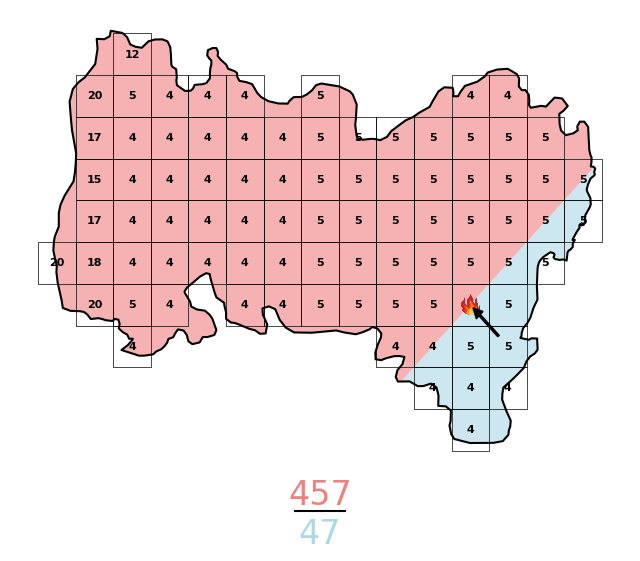

In [37]:
import matplotlib.image as mpimg
from shapely.geometry import LineString
from shapely.ops import split as shp_split, unary_union
from exactextract import exact_extract

# Population density raster (persons/km^2)
pop_tif = os.path.join(
    main_dir, "data", "input", "population_density", "sedac",
    "gpw-v4-population-density-rev11_2015_30_sec_tif",
    "gpw_v4_population_density_rev11_2015_30_sec.tif",
)

# --- Splitting line: same line as the dw4 plot (through fire grid 5818, slope 1) ---
centroid = selected_grids[selected_grids["unq_s__"] == 5818].geometry.centroid.iloc[0]
cp = centroid.y - centroid.x            # line: y = x + cp
arrow_dx, arrow_dy = -1, 1

# --- Split the AC polygon in two along the line ---
poly = selected_polygon.unary_union
minx, miny, maxx, maxy = poly.bounds
M = (maxx - minx) + (maxy - miny)       # extend the line well beyond the polygon
line = LineString([(minx - M, (minx - M) + cp), (maxx + M, (maxx + M) + cp)])

down, up = [], []
for g in shp_split(poly, line).geoms:
    rp = g.representative_point()
    # "under the line" (downwind) side for this plot: y > x + cp
    (down if rp.y > (rp.x + cp) else up).append(g)
down_poly = unary_union(down)
up_poly = unary_union(up)

# --- Population in each sub-polygon from the raster (mean density * area) ---
sub = gpd.GeoDataFrame({"side": ["down", "up"]},
                       geometry=[down_poly, up_poly], crs=selected_polygon.crs)
sub["mean_dens"] = exact_extract(pop_tif, sub, ["mean"], output="pandas")["mean"].values
sub["area_km2"] = sub.to_crs(7755).area / 1e6
sub["population"] = sub["mean_dens"].fillna(0) * sub["area_km2"]
num = round(sub.loc[sub.side == "down", "population"].iloc[0] / 1000, 0)  # light red
den = round(sub.loc[sub.side == "up",   "population"].iloc[0] / 1000, 0)  # light blue

# --- Fire image ---
fire_img = mpimg.imread("../data_output/intermediate/fire.png")

# --- Plotting ---
fig, ax = plt.subplots(figsize=(8, 6))
sub[sub.side == "down"].plot(ax=ax, color="lightcoral", alpha=0.6)
sub[sub.side == "up"].plot(ax=ax, color="lightblue", alpha=0.6)
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5)
selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5)

fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor,
]
ax.imshow(fire_img, extent=img_extent, aspect="auto", zorder=9)
ax.arrow(centroid.x + + 0.015, centroid.y + - 0.015, arrow_dx * 0.01, arrow_dy * 0.01,
         head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11)
ax.axis("off")

# Population label at each grid centroid, in dark letters
for _, row in selected_grids.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, f"{row['population']:.0f}",
            fontsize=8, ha="center", va="center", color="black", fontweight="bold")

# --- Fraction: population under the line (light red) / above the line (light blue) ---
ax.text(0.5, -0.015, f"{num:,.0f}", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, color="lightcoral", clip_on=False)
ax.plot([0.46, 0.54], [-0.085, -0.085], transform=ax.transAxes,
        color="black", lw=1.5, clip_on=False)
ax.text(0.5, -0.10, f"{den:,.0f}", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, color="lightblue", clip_on=False)

save_path = r"C:\Users\rjbar\Dropbox (Personal)\Aplicaciones\Overleaf\sa_fires_politicians\panel_C_upwind.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()


C:\Users\rjbar\AppData\Local\Temp\ipykernel_3168\1166805126.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = selected_grids[selected_grids["unq_s__"] == 5818].geometry.centroid.iloc[0]
C:\Users\rjbar\AppData\Local\Temp\ipykernel_3168\1166805126.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poly = selected_polygon.unary_union


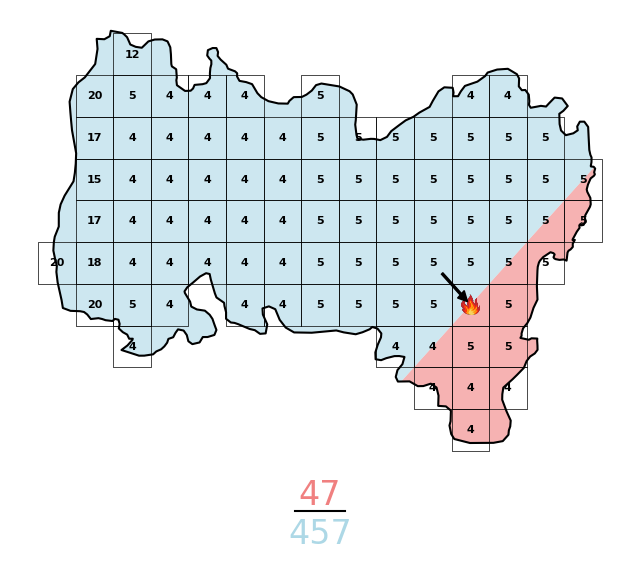

In [36]:
import matplotlib.image as mpimg
from shapely.geometry import LineString
from shapely.ops import split as shp_split, unary_union
from exactextract import exact_extract

# Population density raster (persons/km^2)
pop_tif = os.path.join(
    main_dir, "data", "input", "population_density", "sedac",
    "gpw-v4-population-density-rev11_2015_30_sec_tif",
    "gpw_v4_population_density_rev11_2015_30_sec.tif",
)

# --- Splitting line: same line as the dw3 plot (through fire grid 5818, slope 1) ---
centroid = selected_grids[selected_grids["unq_s__"] == 5818].geometry.centroid.iloc[0]
cp = centroid.y - centroid.x            # line: y = x + cp
arrow_dx, arrow_dy = 1, -1

# --- Split the AC polygon in two along the line ---
poly = selected_polygon.unary_union
minx, miny, maxx, maxy = poly.bounds
M = (maxx - minx) + (maxy - miny)       # extend the line well beyond the polygon
line = LineString([(minx - M, (minx - M) + cp), (maxx + M, (maxx + M) + cp)])

down, up = [], []
for g in shp_split(poly, line).geoms:
    rp = g.representative_point()
    # "under the line" (downwind) side for this plot: y < x + cp
    (down if rp.y < (rp.x + cp) else up).append(g)
down_poly = unary_union(down)
up_poly = unary_union(up)

# --- Population in each sub-polygon from the raster (mean density * area) ---
sub = gpd.GeoDataFrame({"side": ["down", "up"]},
                       geometry=[down_poly, up_poly], crs=selected_polygon.crs)
sub["mean_dens"] = exact_extract(pop_tif, sub, ["mean"], output="pandas")["mean"].values
sub["area_km2"] = sub.to_crs(7755).area / 1e6
sub["population"] = sub["mean_dens"].fillna(0) * sub["area_km2"]
num = round(sub.loc[sub.side == "down", "population"].iloc[0] / 1000, 0)  # light red
den = round(sub.loc[sub.side == "up",   "population"].iloc[0] / 1000, 0)  # light blue

# --- Fire image ---
fire_img = mpimg.imread("../data_output/intermediate/fire.png")

# --- Plotting ---
fig, ax = plt.subplots(figsize=(8, 6))
sub[sub.side == "down"].plot(ax=ax, color="lightcoral", alpha=0.6)
sub[sub.side == "up"].plot(ax=ax, color="lightblue", alpha=0.6)
selected_grids.boundary.plot(ax=ax, color="black", linewidth=0.5)
selected_polygon.plot(ax=ax, color="none", edgecolor="black", linewidth=1.5)

fire_size_factor = 0.005
img_extent = [
    centroid.x - fire_size_factor, centroid.x + fire_size_factor,
    centroid.y - fire_size_factor, centroid.y + fire_size_factor,
]
ax.imshow(fire_img, extent=img_extent, aspect="auto", zorder=9)
ax.arrow(centroid.x + - 0.015, centroid.y + + 0.015, arrow_dx * 0.01, arrow_dy * 0.01,
         head_width=0.005, head_length=0.005, fc="black", ec="black", zorder=11)
ax.axis("off")

# Population label at each grid centroid, in dark letters
for _, row in selected_grids.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, f"{row['population']:.0f}",
            fontsize=8, ha="center", va="center", color="black", fontweight="bold")
    
# --- Fraction: population under the line (light red) / above the line (light blue) ---
ax.text(0.5, -0.015, f"{num:,.0f}", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, color="lightcoral", clip_on=False)
ax.plot([0.46, 0.54], [-0.085, -0.085], transform=ax.transAxes,
        color="black", lw=1.5, clip_on=False)
ax.text(0.5, -0.10, f"{den:,.0f}", transform=ax.transAxes, ha="center", va="top",
        fontsize=24, color="lightblue", clip_on=False)

save_path = r"C:\Users\rjbar\Dropbox (Personal)\Aplicaciones\Overleaf\sa_fires_politicians\panel_B_downwind.png"  # Change to your desired path
plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()
